### Pour lire ce notebook, il suffit de l'ouvrir
### Pour exécuter ce notebook, il faut avoir téléchargé le fichier et l'avoir placé dans son répertoire raw_data
rappel ci-dessous de la marche à suivre pour créér les répertoires projet en local et télécharger les données

### Adresse du repo GitHub pour le projet : 
git@github.com:ArthurVigier/grisounet.git

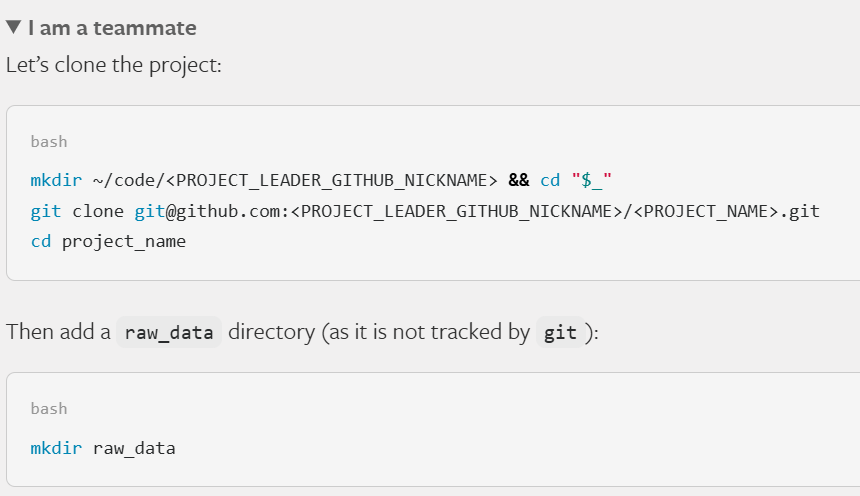

### Lien pour télécharger le dataset 
https://data.mendeley.com/datasets/yd7vw4c5mk/1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# un-comment the following line if you need to install statsmodel
# !python -m pip install statsmodels

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)

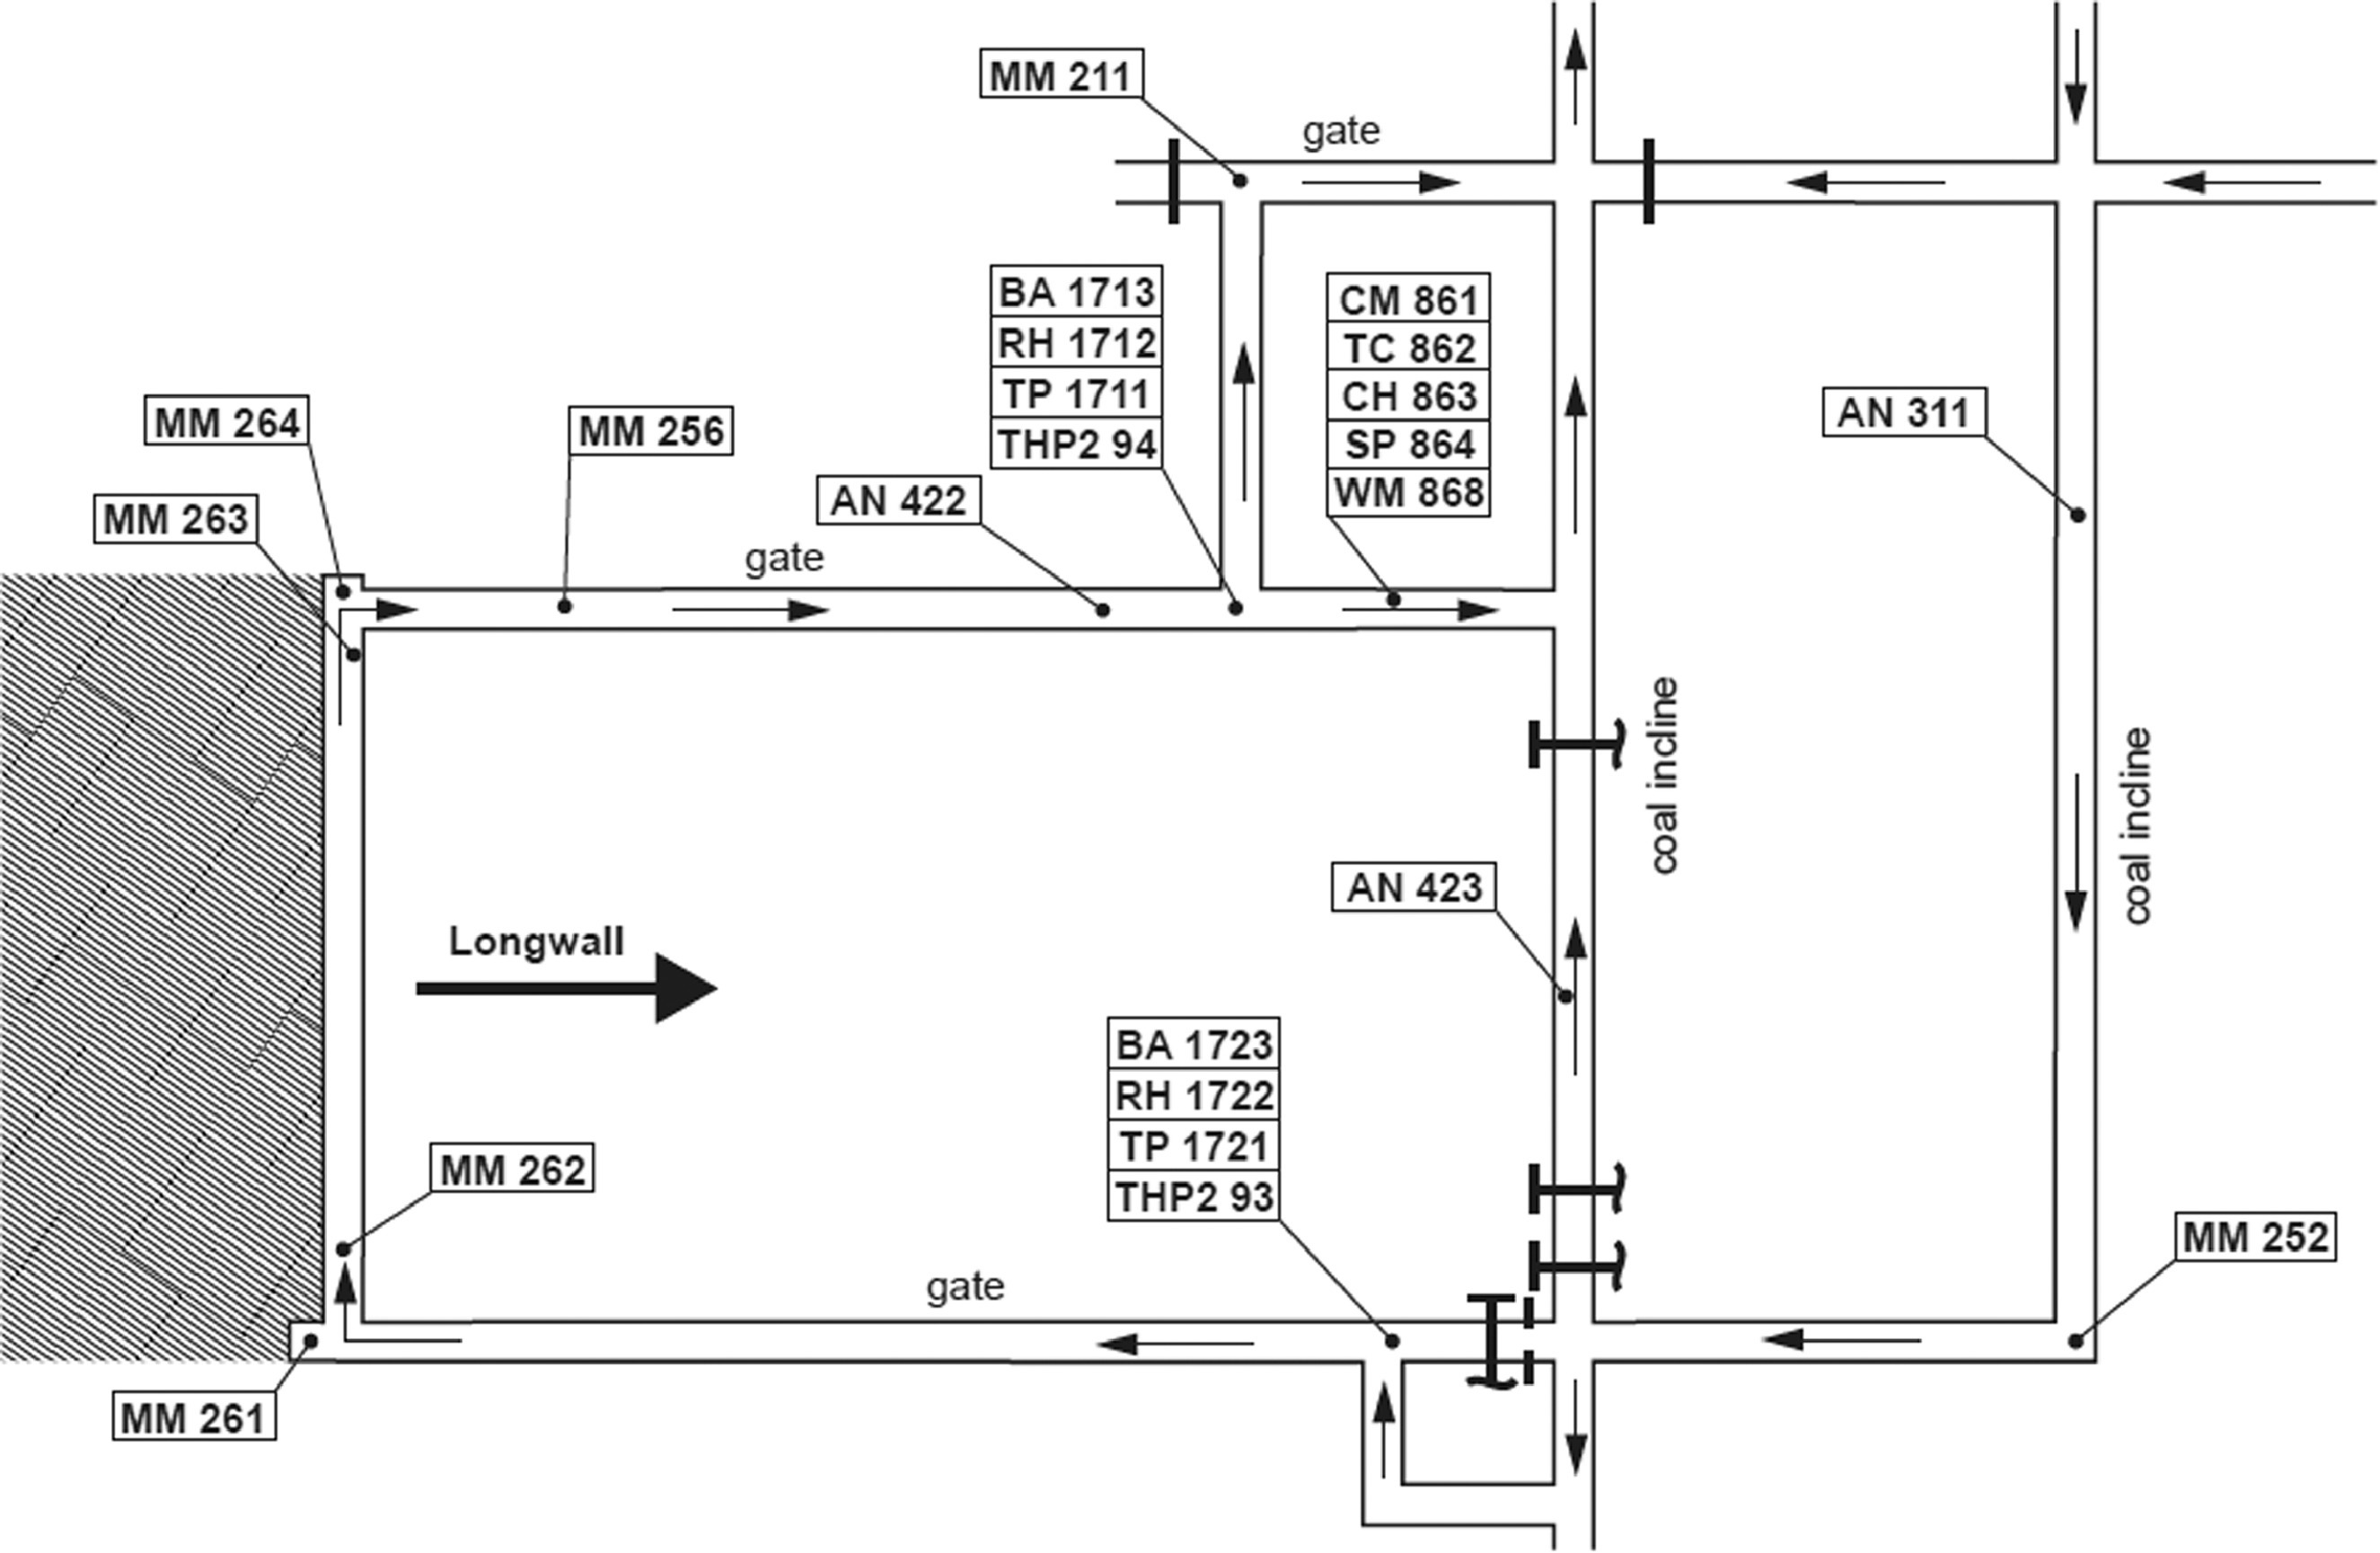

Among the sensors collecting information about the environmental parameters underground, three methane sensors can be distinguished: **MM263, MM264 and MM256**. These sensors, as it is shown in Fig. 1, are located in the most exposed area of the monitored longwall, where the methane released from the longwall accumulates. Therefore, these sensors can indicate the highest concentration of methane released during mining activity, and thus they are of critical importance from the point of view of the explosion hazard.

In [2]:
# creation de la DataFrame df à partir du fichier csv sauvegardé en local dans le répertoire raw_data
df = pd.read_csv('raw_data/methane_data.csv')
df.head(5)

,year,month,day,hour,minute,second,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V
0,2014,3,2,0,0,0,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,6.0,4.0,0.0,0.0,0.0
1,2014,3,2,0,0,1,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,5.0,4.0,0.0,0.0,0.0
2,2014,3,2,0,0,2,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0
3,2014,3,2,0,0,3,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0
4,2014,3,2,0,0,4,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0


In [3]:
# vérif du type des données -> que du numérique dont 6 colonnes pour la date (année/mois/jour/heure/min/sec)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9199930 entries, 0 to 9199929
Data columns (total 34 columns):
 #   Column   Dtype  
---  ------   -----  
 0   year     int64  
 1   month    int64  
 2   day      int64  
 3   hour     int64  
 4   minute   int64  
 5   second   int64  
 6   AN311    float64
 7   AN422    float64
 8   AN423    float64
 9   TP1721   float64
 10  RH1722   int64  
 11  BA1723   float64
 12  TP1711   float64
 13  RH1712   int64  
 14  BA1713   float64
 15  MM252    float64
 16  MM261    float64
 17  MM262    float64
 18  MM263    float64
 19  MM264    float64
 20  MM256    float64
 21  MM211    float64
 22  CM861    float64
 23  CR863    int64  
 24  P_864    float64
 25  TC862    float64
 26  WM868    float64
 27  AMP1_IR  float64
 28  AMP2_IR  float64
 29  DMP3_IR  float64
 30  DMP4_IR  float64
 31  AMP5_IR  float64
 32  F_SIDE   float64
 33  V        float64
dtypes: float64(25), int64(9)
memory usage: 2.3 GB


In [4]:
df.sample(3)

,year,month,day,hour,minute,second,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V
8402643,2014,6,7,7,4,3,2.1,1.9,1.4,26.0,56,1110.4,29.1,72,1110.2,0.0,0.0,0.0,0.1,0.2,0.5,0.7,51.6,90,93.8,33.6,2.77,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4876917,2014,4,27,11,41,57,3.6,1.7,1.4,26.2,54,1097.5,28.8,67,1096.7,0.0,0.0,0.1,0.3,0.3,0.3,0.8,46.8,76,95.0,33.0,2.30,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4917686,2014,4,27,23,1,26,3.8,1.6,1.4,26.1,53,1096.8,28.8,66,1096.0,0.0,0.0,0.0,0.3,0.3,0.2,0.8,46.4,74,94.9,32.9,2.24,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# confirmation de ce qu'il n'y a pas de valeurs manquantes (comme indiqué dans la description du dataset)
df.isnull().sum().sort_values(ascending=False)

year       0
month      0
day        0
hour       0
minute     0
second     0
AN311      0
AN422      0
AN423      0
TP1721     0
RH1722     0
BA1723     0
TP1711     0
RH1712     0
BA1713     0
MM252      0
MM261      0
MM262      0
MM263      0
MM264      0
MM256      0
MM211      0
CM861      0
CR863      0
P_864      0
TC862      0
WM868      0
AMP1_IR    0
AMP2_IR    0
DMP3_IR    0
DMP4_IR    0
AMP5_IR    0
F_SIDE     0
V          0
dtype: int64

In [6]:
# principales statistiques descriptives -> concentration en méthane relevée par MM256/263/264 : de l'ordre de 0.4% / 75% au-dessous de 0.5% / max 40%
df.describe()

,year,month,day,hour,minute,second,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V
count,9199930.0,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06
mean,2014.0,4.301335e+00,1.486756e+01,1.147565e+01,2.949708e+01,2.949997e+01,3.483730e+00,1.654854e+00,1.497736e+00,2.547688e+01,4.928308e+01,1.106161e+03,2.889449e+01,6.868665e+01,1.105597e+03,3.809244e-02,4.944626e-02,5.067284e-02,2.484955e-01,3.274317e-01,4.297198e-01,6.995559e-01,3.292010e+01,7.508092e+01,8.696697e+01,2.989809e+01,1.802531e+00,5.853846e+00,5.741290e+00,4.200591e+00,3.969738e+00,4.143130e-01,9.374555e-02,1.346978e+00
std,0.0,1.031884e+00,8.713892e+00,6.920225e+00,1.731798e+01,1.731811e+01,6.105680e-01,1.282543e-01,3.304544e-01,9.320548e-01,6.142636e+00,7.625362e+00,7.568178e-01,7.267818e+00,7.616580e+00,1.213477e-01,1.250277e-01,1.357671e-01,1.973360e-01,2.055773e-01,2.036265e-01,1.508808e-01,2.139457e+01,5.516095e+01,2.915783e+01,9.898455e+00,1.319706e+00,2.441276e+01,2.425026e+01,1.734187e+01,1.731265e+01,1.096601e+01,2.914651e-01,5.996678e+00
min,2014.0,3.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.660000e+02,0.000000e+00,-2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e-01,0.000000e+00,-2.000000e-01,-2.000000e+00,-2.000000e+00,0.000000e+00,-2.000000e+00,-2.000000e-01,-8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.550000e+02,-2.550000e+02,-2.550000e+02,-2.550000e+02,-2.550000e+02,0.000000e+00,0.000000e+00
25%,2014.0,3.000000e+00,7.000000e+00,5.000000e+00,1.400000e+01,1.400000e+01,3.300000e+00,1.600000e+00,1.400000e+00,2.470000e+01,4.500000e+01,1.101000e+03,2.830000e+01,6.400000e+01,1.100500e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-01,2.000000e-01,3.000000e-01,6.000000e-01,2.000000e+00,3.100000e+01,9.340000e+01,3.240000e+01,5.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2014.0,4.000000e+00,1.400000e+01,1.100000e+01,2.900000e+01,2.900000e+01,3.600000e+00,1.600000e+00,1.400000e+00,2.540000e+01,4.800000e+01,1.105900e+03,2.880000e+01,6.900000e+01,1.105300e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-01,3.000000e-01,4.000000e-01,7.000000e-01,4.370000e+01,7.800000e+01,9.420000e+01,3.290000e+01,2.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2014.0,5.000000e+00,2.200000e+01,1.700000e+01,4.400000e+01,4.400000e+01,3.800000e+00,1.700000e+00,1.500000e+00,2.610000e+01,5.400000e+01,1.109400e+03,2.940000e+01,7.400000e+01,1.108900e+03,0.000000e+00,1.000000e-01,1.000000e-01,3.000000e-01,4.000000e-01,5.000000e-01,8.000000e-01,4.890000e+01,1.030000e+02,9.570000e+01,3.350000e+01,2.790000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2014.0,6.000000e+00,3.100000e+01,2.300000e+01,5.900000e+01,5.900000e+01,5.000000e+00,2.400000e+00,5.300000e+00,2.790000e+01,7.100000e+01,1.131700e+03,3.120000e+01,8.600000e+01,1.130900e+03,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,4.000000e+01,3.000000e+01,3.000000e+01,6.770000e+01,2.580000e+02,4.354000e+02,4.050000e+01,6.390000e+00,9.880000e+02,1.009000e+03,2.160000e+02,1.980000e+02,1.210000e+02,1.000000e+00,1.000000e+02


In [7]:
# création d'une colonne time traduisant en format datetime les indications des 6 colonnes temporelles
df['time'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])

# utilisation de la colonne 'time' comme index pour la DataFrame df
df.set_index('time', inplace=True)

# élimination des colonnes temporelles - plus nécessaires à ce stade
df.drop(columns=['year', 'month', 'day', 'hour', 'minute', 'second'], inplace=True)

df.head(3)

,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-03-02 00:00:00,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,6.0,4.0,0.0,0.0,0.0
2014-03-02 00:00:01,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,5.0,4.0,0.0,0.0,0.0
2014-03-02 00:00:02,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0


In [8]:
df.shape

(9199930, 28)

In [9]:
# création d'une liste des colonnes initiales
initial_features = df.columns
initial_features

Index(['AN311', 'AN422', 'AN423', 'TP1721', 'RH1722', 'BA1723', 'TP1711',
       'RH1712', 'BA1713', 'MM252', 'MM261', 'MM262', 'MM263', 'MM264',
       'MM256', 'MM211', 'CM861', 'CR863', 'P_864', 'TC862', 'WM868',
       'AMP1_IR', 'AMP2_IR', 'DMP3_IR', 'DMP4_IR', 'AMP5_IR', 'F_SIDE', 'V'],
      dtype='str')

In [10]:
# Identification des séquences d'observations présentant un taux de méthane supérieur au seuil d'alerte

# Création d'une colonne signalant les lignes pour lesquelles au moins l'un des 3 capteurs principaux est en alerte
alert_rate = 1.0
patience = 5  # nbre de secondes pendant lesquelles au sein d'une séquence le taux de méthane peut revenir au-dessous du seuil d'alerte
above_alert = df[["MM256", "MM263", "MM264"]].ge(alert_rate).any(axis=1)
df["ALERT_RAW"] = above_alert.astype(int)  # signale les observations supérieures au seuil d'alerte sur au moins l'un des 3 capteurs princ.

# Repérage de la position des lignes pour mesurer la taille des intervalles au-dessous du seuil au sein d'une séquence d'alerte
pos = pd.Series(np.arange(len(df)), index=df.index, dtype="float")
prev_alert_pos = pos.where(above_alert).ffill()
next_alert_pos = pos.where(above_alert).bfill()

# Compteur des secondes entre seuils d'alerte
gap_len = next_alert_pos - prev_alert_pos - 1

# Intégrer les baisses temporaires (d'une durée inférieurs à notre "patience") au sein d'un épisode (avant et après au-dessus du seuil d'alerte )
short_dip = (
    ~above_alert
    & prev_alert_pos.notna()
    & next_alert_pos.notna()
    & (gap_len <= patience))
event_flag = above_alert | short_dip

# Signaler les séquences d'alerte dans la df dans une colonne 'ALERT'
df["ALERT"] = event_flag.astype(int)

# Noter dans la colonne 'ALERT_START' le début de la séquence d'alerte
df["ALERT_START"] = (event_flag & ~event_flag.shift(1, fill_value=False)).astype(int)

# Noter dans la colonne 'ALERT_END' la fin de la séquence d'alerte
df["ALERT_END"] = (event_flag & ~event_flag.shift(-1, fill_value=False)).astype(int)

# Ajouter une colonne avec un numéro d'identification de chaque séquence d'alerte
df["ALERT_SEQ_ID"] = df["ALERT_START"].cumsum().where(event_flag)

# Voir le résultat sur les 3 premières lignes de la df
df.sample(3)

,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V,ALERT_RAW,ALERT,ALERT_START,ALERT_END,ALERT_SEQ_ID
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-06-07 02:59:41,1.8,1.8,1.5,26.2,57,1109.6,29.9,83,1109.4,0.1,0.0,0.0,0.1,0.3,0.7,0.8,54.7,48,93.6,34.2,2.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN
2014-04-08 18:35:00,3.4,1.3,1.2,25.0,54,1099.5,28.9,67,1099.2,0.0,0.2,0.2,0.4,0.3,0.4,0.8,48.4,86,93.7,33.0,2.52,5.0,5.0,5.0,4.0,0.0,0.0,0.0,0,0,0,0,NaN
2014-04-07 05:02:04,3.8,1.6,1.4,24.5,49,1111.6,28.6,70,1111.0,0.0,0.1,0.1,0.4,0.1,0.3,0.7,50.2,97,95.5,32.7,2.82,188.0,103.0,80.0,63.0,9.0,0.0,11.2,0,0,0,0,NaN


In [11]:
# Estimer la durée moyenne des séquences d'alerte (en secondes):
seq_lengths = (
    df[df["ALERT"] == 1]
    .groupby("ALERT_SEQ_ID")
    .size())

seq_lengths.describe()

count     5195.000000
mean        40.753802
std        252.309830
min          2.000000
25%          4.000000
50%          8.000000
75%         24.000000
max      14999.000000
dtype: float64

### la moitié des séquences d'alerte durent 8 secondes ou moins, 3/4 durent moins de 24 secondes
### 1 séquence étonamment longue (plus de 4 heures) 

99th percentile cutoff: 580 seconds
Sequences removed: 52
Rows removed: 74139


,ALERT_SEQ_ID,start_time,end_time,n_obs,raw_alert_obs,max_MM256,max_MM263,max_MM264,duration_s,bridged_obs
1836,1837.0,2014-04-04 10:45:22,2014-04-04 14:55:20,14999,14999,1.5,0.7,0.7,14999,0
2019,2020.0,2014-04-11 02:13:06,2014-04-11 03:28:47,4542,4542,0.8,1.3,1.1,4542,0
99,100.0,2014-03-15 07:06:19,2014-03-15 07:47:41,2483,2483,0.8,0.7,1.6,2483,0
3146,3147.0,2014-04-25 00:50:55,2014-04-25 01:31:30,2436,2422,0.6,0.4,1.8,2436,14
2100,2101.0,2014-04-11 07:46:29,2014-04-11 08:24:28,2280,2278,1.1,0.9,1.7,2280,2
4461,4462.0,2014-06-11 10:04:23,2014-06-11 10:36:06,1904,1904,1.4,0.2,0.4,1904,0
1361,1362.0,2014-03-31 14:23:24,2014-03-31 14:54:07,1844,1782,0.5,1.2,0.3,1844,62
3142,3143.0,2014-04-25 00:16:27,2014-04-25 00:46:48,1822,1796,0.9,0.8,1.4,1822,26
1713,1714.0,2014-04-04 06:59:11,2014-04-04 07:28:48,1778,1758,1.3,0.6,0.8,1778,20
3517,3518.0,2014-05-22 23:58:36,2014-05-23 00:27:21,1726,1718,1.3,0.6,0.6,1726,8


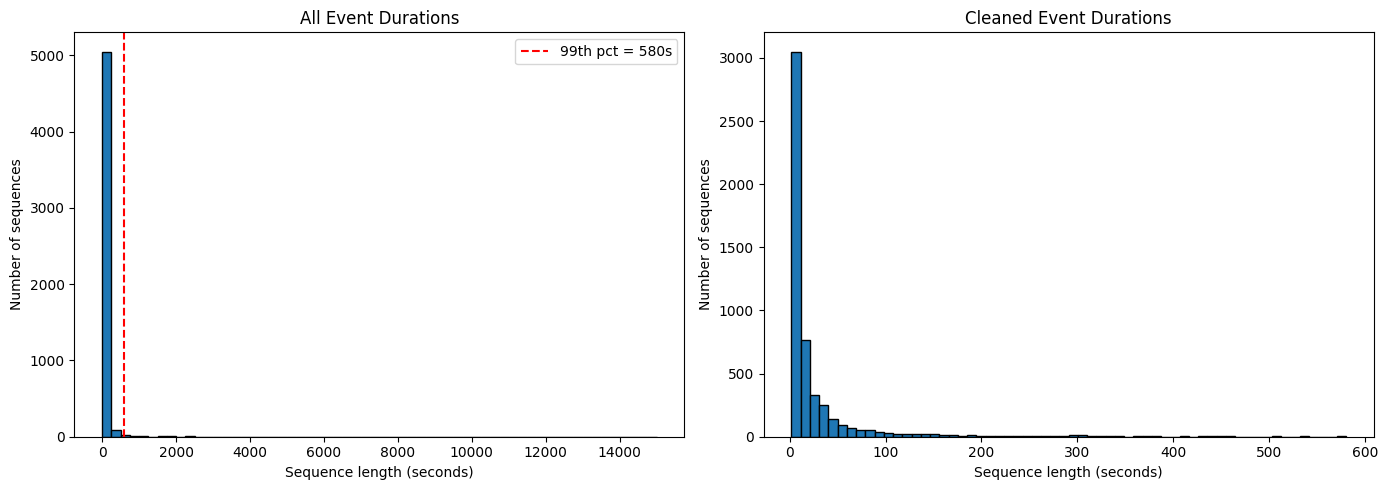

In [12]:
# Distribution de la longueur des séquences après élimination du 1% des observations avec les longueurs les plus élevées

seq_summary = (
    df[df["ALERT"] == 1]
    .reset_index()
    .groupby("ALERT_SEQ_ID")
    .agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        n_obs=("time", "size"),
        raw_alert_obs=("ALERT_RAW", "sum"),
        max_MM256=("MM256", "max"),
        max_MM263=("MM263", "max"),
        max_MM264=("MM264", "max"))
    .reset_index())

seq_summary["duration_s"] = (seq_summary["end_time"] - seq_summary["start_time"]).dt.total_seconds().astype(int) + 1

seq_summary["bridged_obs"] = seq_summary["n_obs"] - seq_summary["raw_alert_obs"]

# Ecartement des séquences inhabituellement longues
duration_cutoff = seq_summary["duration_s"].quantile(0.99)

bad_seq_ids = seq_summary.loc[
    seq_summary["duration_s"] > duration_cutoff,
    "ALERT_SEQ_ID"]

excluded_sequences = (
    seq_summary[seq_summary["ALERT_SEQ_ID"].isin(bad_seq_ids)]
    .sort_values("duration_s", ascending=False)
    .copy())

df_clean = df[~df["ALERT_SEQ_ID"].isin(bad_seq_ids)].copy()

# Comparaison avant/après écartement des séquences les plus longues
seq_lengths_all = seq_summary["duration_s"]

seq_lengths_clean = (
    df_clean[df_clean["ALERT"] == 1]
    .groupby("ALERT_SEQ_ID")
    .size())

print(f"99th percentile cutoff: {duration_cutoff:.0f} seconds")
print(f"Sequences removed: {len(bad_seq_ids)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

display(excluded_sequences.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(seq_lengths_all, bins=60, edgecolor="black")
axes[0].axvline(duration_cutoff, color="red", linestyle="--", label=f"99th pct = {duration_cutoff:.0f}s")
axes[0].set_title("All Event Durations")
axes[0].set_xlabel("Sequence length (seconds)")
axes[0].set_ylabel("Number of sequences")
axes[0].legend()

axes[1].hist(seq_lengths_clean, bins=60, edgecolor="black")
axes[1].set_title("Cleaned Event Durations")
axes[1].set_xlabel("Sequence length (seconds)")
axes[1].set_ylabel("Number of sequences")

plt.tight_layout()
plt.show()

### le top % des séquences les plus longues va de 10 minutes à 4 heures

In [13]:
# création d'une liste de features principales : n'intégre pas le temps, ne retient que les 3 méthanomètres principaux
main_features = ['AN311', 'AN422', 'AN423', 'TP1721', 'RH1722', 'BA1723', 'TP1711', 'RH1712', 'BA1713', 'MM263', 'MM264', 'MM256', 'CM861',
       'CR863', 'P_864', 'TC862', 'WM868', 'AMP1_IR', 'AMP2_IR', 'DMP3_IR', 'DMP4_IR', 'AMP5_IR', 'F_SIDE', 'V']

In [14]:
# nombre d'observations de M256, MM263, MM264 supérieures à 1% et 1.5%
df['ALERT_256'] = (df['MM256'] > 1).astype(int)
df['STOP_256'] = (df['MM256'] > 1.5).astype(int)
df['ALERT_263'] = (df['MM263'] > 1).astype(int)
df['STOP_263'] = (df['MM263'] > 1.5).astype(int)
df['ALERT_264'] = (df['MM264'] > 1).astype(int)
df['STOP_264'] = (df['MM264'] > 1.5).astype(int)
df.head(3)

,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V,ALERT_RAW,ALERT,ALERT_START,ALERT_END,ALERT_SEQ_ID,ALERT_256,STOP_256,ALERT_263,STOP_263,ALERT_264,STOP_264
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-03-02 00:00:00,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,6.0,4.0,0.0,0.0,0.0,0,0,0,0,NaN,0,0,0,0,0,0
2014-03-02 00:00:01,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,5.0,4.0,0.0,0.0,0.0,0,0,0,0,NaN,0,0,0,0,0,0
2014-03-02 00:00:02,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0,0,0,0,0,NaN,0,0,0,0,0,0


### Les observations au-dessus du seuil d'alerte (1% de méthane dans l'air) sont TRES MINORITAIRES : de l'ordre d'un pourcent du total des observations
### Celles au-dessus de 1.5% sont EXTREMEMENT RARES : de l'ordre de 0.05% du total des observations

In [15]:
# nombre d'observations de MM256 au-dessus des seuils de 1% (alerte) et 1.5% (arrêt du banc de coupe):
print("observations MM256 au-dessus de 1% de Methane (seuil d'alerte):", df['ALERT_256'].sum(), " soit ", round(df['ALERT_256'].sum() *100 / len(df),1), "% des observations")
print("observations MM256 au-dessus de 1.5% de Methane (seuil d'arrêt du banc de coupe):", df['STOP_256'].sum(), " soit ", round(df['STOP_256'].sum() *100 / len(df),2), "% des observations")

observations MM256 au-dessus de 1% de Methane (seuil d'alerte): 50288  soit  0.5 % des observations
observations MM256 au-dessus de 1.5% de Methane (seuil d'arrêt du banc de coupe): 947  soit  0.01 % des observations


In [16]:
# nombre d'observations de MM263 au-dessus des seuils de 1% (alerte) et 1.5% (arrêt du banc de coupe):
print("observations MM263 au-dessus de 1% de Methane (seuil d'alerte):", df['ALERT_263'].sum(), " soit ", round(df['ALERT_263'].sum() *100 / len(df),1), "% des observations")
print("observations MM263 au-dessus de 1.5% de Methane (seuil d'arrêt du banc de coupe):", df['STOP_263'].sum(), " soit ", round(df['STOP_263'].sum() *100 / len(df),2), "% des observations")

observations MM263 au-dessus de 1% de Methane (seuil d'alerte): 10200  soit  0.1 % des observations
observations MM263 au-dessus de 1.5% de Methane (seuil d'arrêt du banc de coupe): 1034  soit  0.01 % des observations


In [17]:
# nombre d'observations de MM264 au-dessus des seuils de 1% (alerte) et 1.5% (arrêt du banc de coupe):
print("observations MM264 au-dessus de 1% de Methane (seuil d'alerte):", df['ALERT_264'].sum(), " soit ", round(df['ALERT_264'].sum() *100 / len(df),1), "% des observations")
print("observations MM264 au-dessus de 1.5% de Methane (seuil d'arrêt du banc de coupe):", df['STOP_264'].sum(), " soit ", round(df['STOP_264'].sum() *100 / len(df),2), "% des observations")

observations MM264 au-dessus de 1% de Methane (seuil d'alerte): 38855  soit  0.4 % des observations
observations MM264 au-dessus de 1.5% de Methane (seuil d'arrêt du banc de coupe): 2482  soit  0.03 % des observations


## Valeurs prises par les différents capteurs, regroupés par type

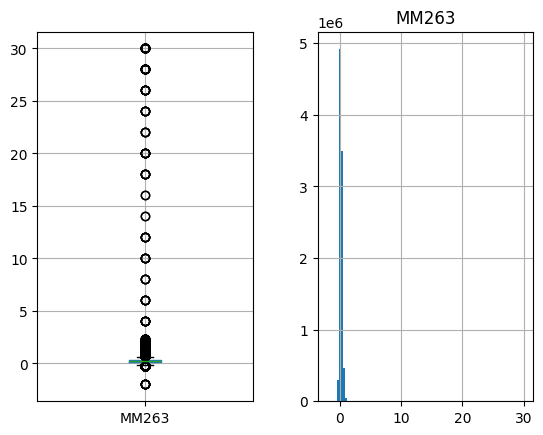

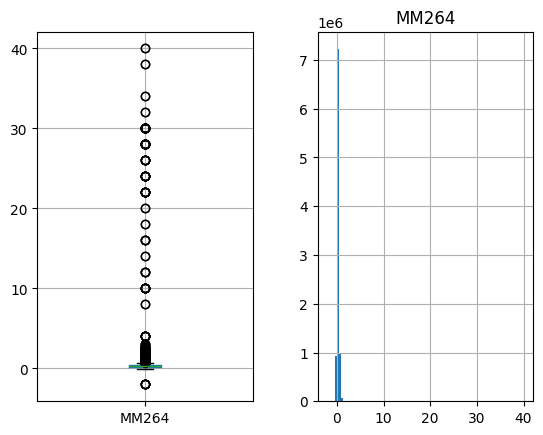

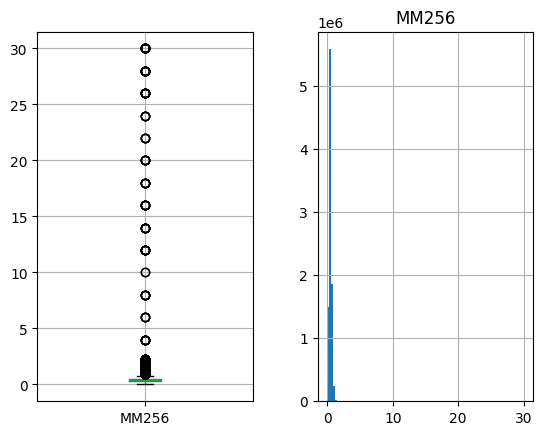

In [ ]:
# Représentation boxplot et histogram pour les 3 principaux méthanomètres (relevé de concentration de méthane dans l'air des galeries)
for feature in ['MM263', 'MM264', 'MM256'] :
    fig, ax = plt.subplots(1,2)
    df[[feature]].boxplot(ax=ax[0]);
    df[[feature]].hist(ax=ax[1],bins=100);
    plt.show()

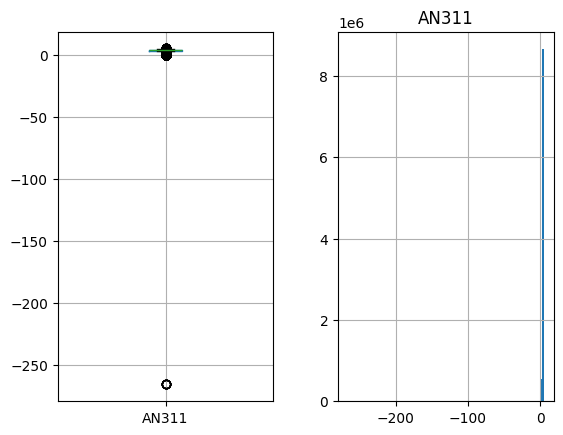

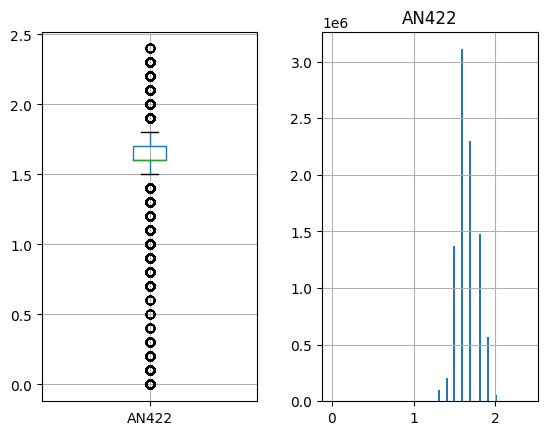

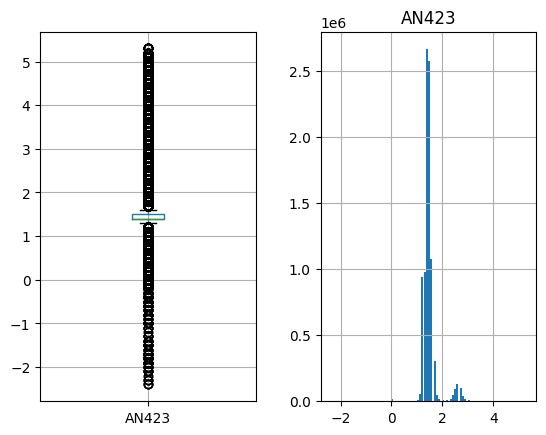

In [21]:
# Représentation boxplot et histogram pour les 3 anémomètres (relevé de débit d'air dans les galeries):
for feature in ['AN311', 'AN422', 'AN423'] :
    fig, ax = plt.subplots(1,2)
    df[[feature]].boxplot(ax=ax[0]);
    df[[feature]].hist(ax=ax[1],bins=100);
    plt.show()

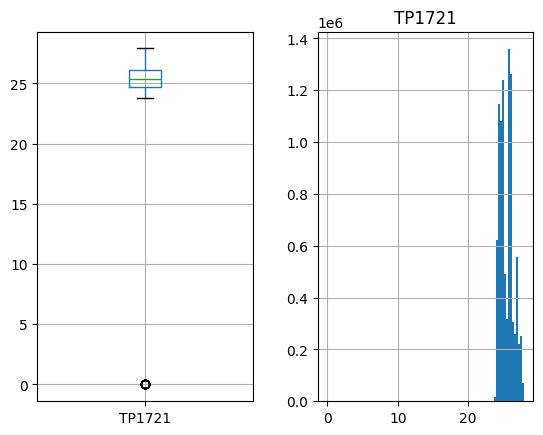

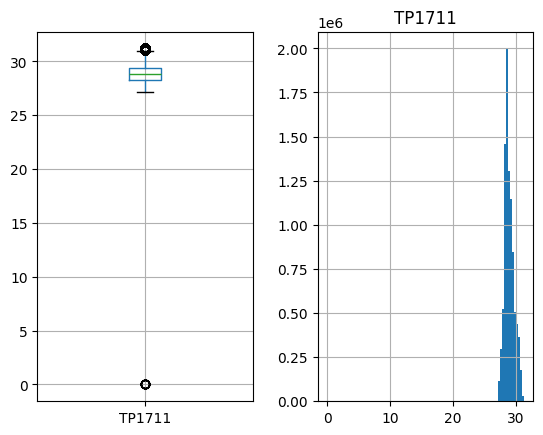

In [22]:
# Représentation boxplot et histogram pour les thermomètres (relevé de température de l'air dans les galeries):
for feature in ['TP1721', 'TP1711'] :
    fig, ax = plt.subplots(1,2)
    df[[feature]].boxplot(ax=ax[0]);
    df[[feature]].hist(ax=ax[1],bins=100);
    plt.show()

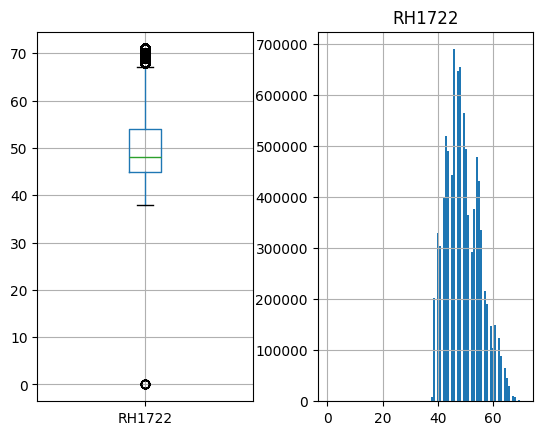

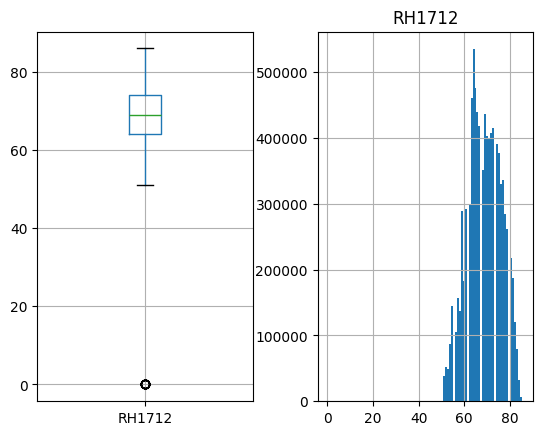

In [23]:
# Représentation boxplot et histogram pour les hygromètres (relevé de degré d'humidité de l'air dans les galeries) :
for feature in ['RH1722', 'RH1712'] :
    fig, ax = plt.subplots(1,2)
    df[[feature]].boxplot(ax=ax[0]);
    df[[feature]].hist(ax=ax[1],bins=100);
    plt.show()

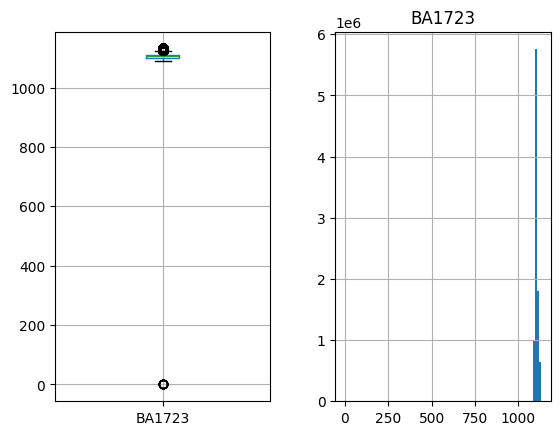

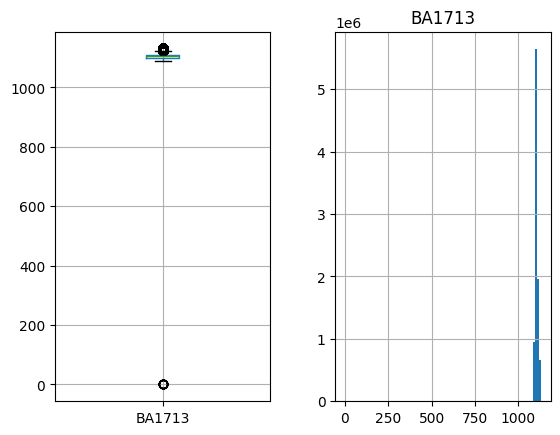

In [24]:
# Représentation boxplot et histogram pour les baromètres (relevé de pression atmosphérique dans les galeries) :
for feature in ['BA1723', 'BA1713'] :
    fig, ax = plt.subplots(1,2)
    df[[feature]].boxplot(ax=ax[0]);
    df[[feature]].hist(ax=ax[1],bins=100);
    plt.show()

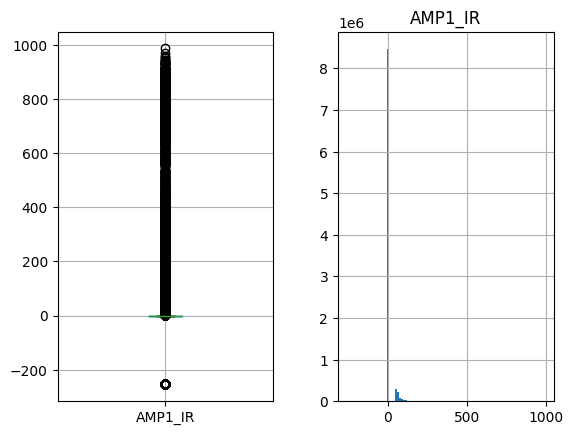

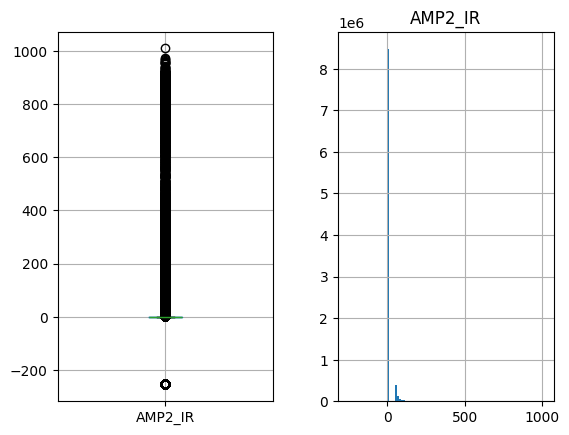

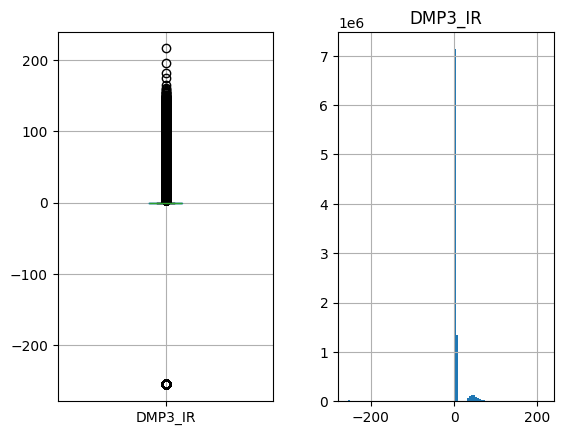

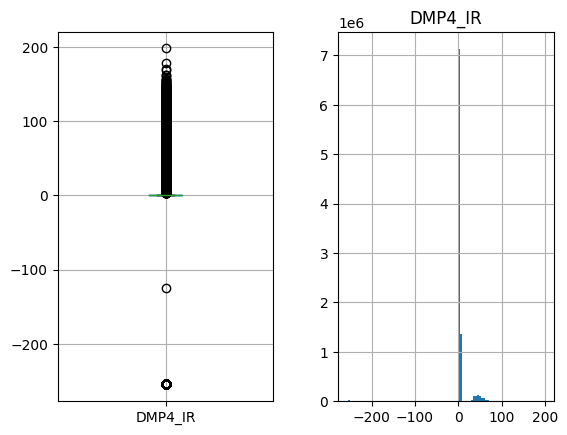

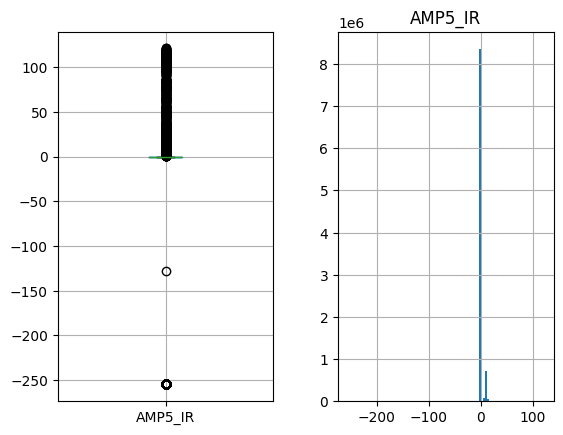

In [25]:
# Représentation boxplot et histogram pour les ampèremètres (relevé de l'intensité du courant dans les moteurs du banc de coupe) :
for feature in ['AMP1_IR', 'AMP2_IR', 'DMP3_IR', 'DMP4_IR', 'AMP5_IR'] :
    fig, ax = plt.subplots(1,2)
    df[[feature]].boxplot(ax=ax[0]);
    df[[feature]].hist(ax=ax[1],bins=100);
    plt.show()

In [26]:
# décision de remplacer les colonnes liées à l'ampérage du courant dans les différents moteurs du banc de coupe par une valeur moyenne
df['AMP_AVG'] = df[['AMP1_IR', 'AMP2_IR', 'DMP3_IR', 'DMP4_IR', 'AMP5_IR']].mean(axis=1)
df.drop(columns=['AMP1_IR', 'AMP2_IR', 'DMP3_IR', 'DMP4_IR', 'AMP5_IR'], inplace=True)

# drop des colonnes STOP_xxx et ALERT_xxx dont nous n'avons plus besoin
df.drop(columns=['STOP_256', 'STOP_263', 'STOP_264', 'ALERT_256', 'ALERT_263', 'ALERT_264'], inplace=True)

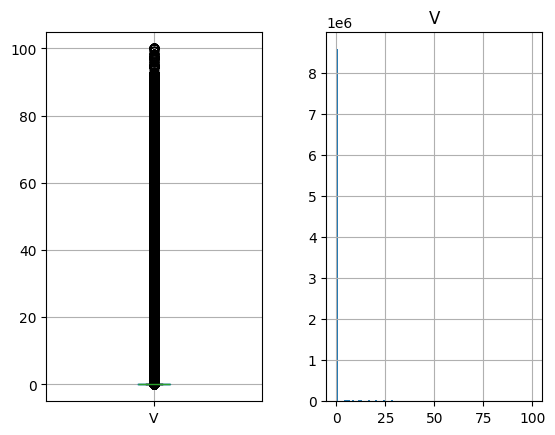

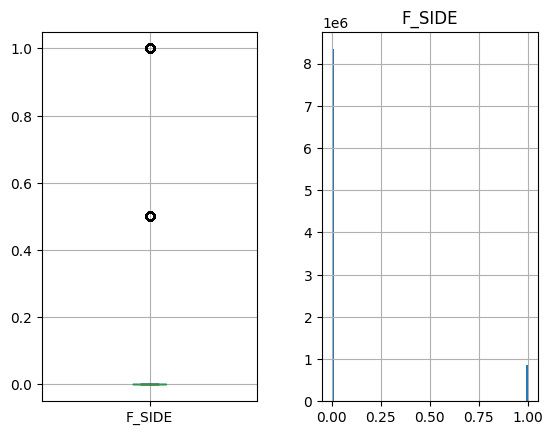

In [27]:
# Représentation boxplot et histogram pour les variables liées à la vitesse et à la direction du banc de coupe :
# --> le banc de coupe se déplace de façon continue dans une direction, puis retourne à sa position de départ (1/9e du temps)
for feature in ['V', 'F_SIDE'] :
    fig, ax = plt.subplots(1,2)
    df[[feature]].boxplot(ax=ax[0]);
    df[[feature]].hist(ax=ax[1],bins=100);
    plt.show()

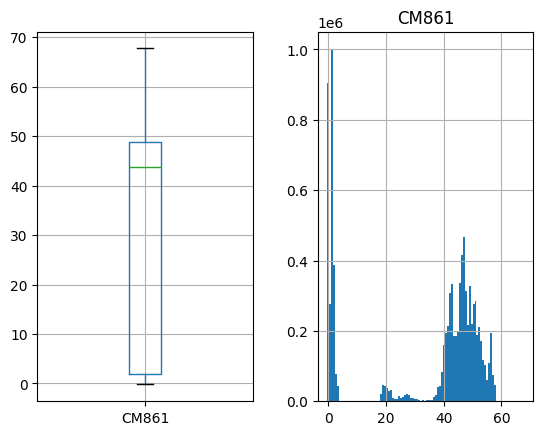

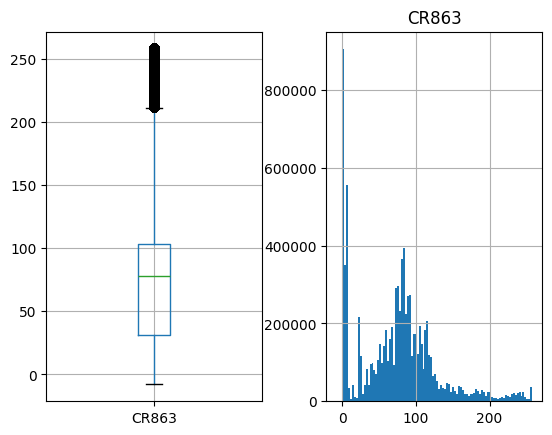

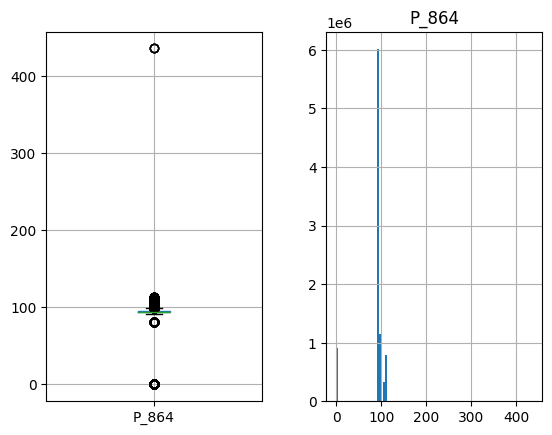

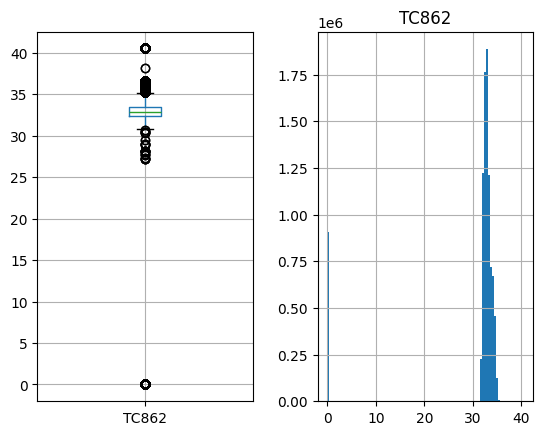

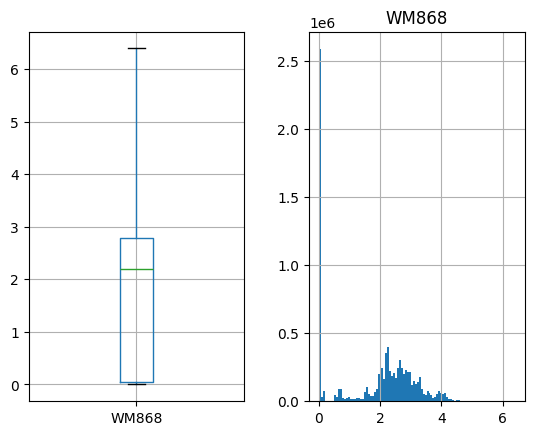

In [28]:
# Représentation boxplot et histogram pour les variables liées au process de drainage du méthane :
for feature in ['CM861', 'CR863', 'P_864', 'TC862', 'WM868'] :
    fig, ax = plt.subplots(1,2)
    df[[feature]].boxplot(ax=ax[0]);
    df[[feature]].hist(ax=ax[1],bins=100);
    plt.show()

In [29]:
# création de la liste de colonnes à "scaler"
features_to_scale = ['AN311', 'AN422', 'AN423', 'TP1721', 'RH1722', 'BA1723', 'TP1711', 'RH1712', 'BA1713', 'MM252', 'MM261', 'MM262', 'MM263',\
                     'MM264', 'MM256', 'MM211', 'CM861','CR863', 'P_864', 'TC862', 'WM868', 'AMP_AVG', 'F_SIDE', 'V']

In [ ]:
# MinMaxScaler because outliers are a full part of the set
mm_scaler = MinMaxScaler()
for feature in features_to_scale :
    df[feature] = mm_scaler.fit_transform(df[[feature]])
df.head(3)

In [48]:
# Création d'une DataFrame réduite (moins de features) pour obtenir une correlation matrix lisible pour MM256
MM256_features = ['AN422', 'TP1711', 'RH1712', 'BA1713', 'MM256', 'CM861', 'CR863', 'P_864', 'TC862', 'WM868', 'AMP_AVG', 'F_SIDE', 'V']
MM256_df = df[MM256_features]
MM256_df.head(3)

,AN422,TP1711,RH1712,BA1713,MM256,CM861,CR863,P_864,TC862,WM868,AMP_AVG,F_SIDE,V
time,,,,,,,,,,,,,
2014-03-02 00:00:00,0.666667,0.875,0.627907,0.969759,0.01,0.002946,0.030075,0.0,0.0,0.0,0.527302,0.0,0.0
2014-03-02 00:00:01,0.666667,0.875,0.627907,0.969759,0.01,0.002946,0.030075,0.0,0.0,0.0,0.526895,0.0,0.0
2014-03-02 00:00:02,0.666667,0.875,0.627907,0.969759,0.01,0.002946,0.030075,0.0,0.0,0.0,0.527302,0.0,0.0


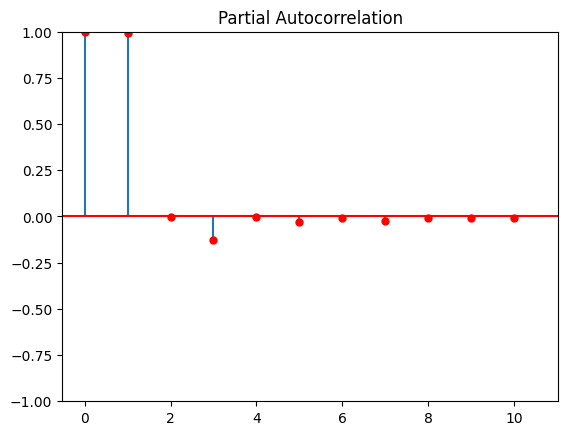

In [50]:
# Partial Auto-Correlation graph pour méthanomètre MM256 --> corrélé uniquement aux qq secondes précédentes: les conditions varient très vite
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(MM256_df.MM256, lags=10, c='r');

,AN422,TP1711,RH1712,BA1713,MM256,CM861,CR863,P_864,TC862,WM868,AMP_AVG,F_SIDE,V
AN422,1.000000,-0.021811,0.030346,0.115279,-0.163638,-0.178298,-0.225577,-0.287676,-0.270949,-0.196574,-0.063488,-0.077864,-0.062281
TP1711,-0.021811,1.000000,0.859664,-0.138311,0.495142,0.346962,0.309352,0.397684,0.517102,0.297895,-0.052704,-0.063212,-0.028028
RH1712,0.030346,0.859664,1.000000,-0.105403,0.559874,0.215475,0.226390,0.282826,0.382687,0.188456,0.070671,0.070438,0.088759
BA1713,0.115279,-0.138311,-0.105403,1.000000,-0.142277,-0.184157,-0.177840,-0.339859,-0.354181,-0.170790,0.006736,0.051205,0.034642
MM256,-0.163638,0.495142,0.559874,-0.142277,1.000000,0.189681,0.265944,0.285573,0.330124,0.227712,0.090923,0.102797,0.109287
CM861,-0.178298,0.346962,0.215475,-0.184157,0.189681,1.000000,0.680281,0.412577,0.515454,0.936710,-0.067137,-0.084113,-0.046206
CR863,-0.225577,0.309352,0.226390,-0.177840,0.265944,0.680281,1.000000,0.359362,0.455165,0.850001,-0.002345,0.040666,0.040715
P_864,-0.287676,0.397684,0.282826,-0.339859,0.285573,0.412577,0.359362,1.000000,0.978125,0.356199,-0.035396,-0.047348,-0.015133
TC862,-0.270949,0.517102,0.382687,-0.354181,0.330124,0.515454,0.455165,0.978125,1.000000,0.456044,-0.048824,-0.064496,-0.025840
WM868,-0.196574,0.297895,0.188456,-0.170790,0.227712,0.936710,0.850001,0.356199,0.456044,1.000000,-0.036889,-0.027376,-0.006335


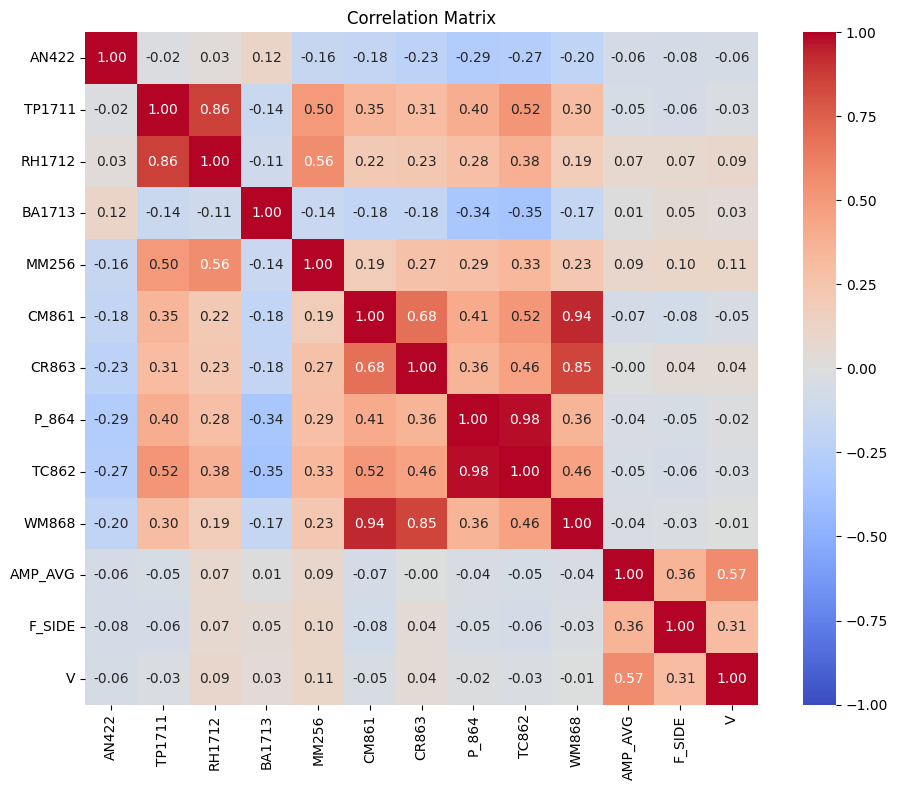

In [51]:
# Correlation matrix sur un jeu de colonnes réduit (MM256) pour meilleure lisibilité

corr = MM256_df.corr(method="pearson")

display(corr)  # matrix as table

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [52]:
# Calcul du VIF (Variance Inflation Factor) pour repérer la multicolinéarité entre variables explicatives

# Variables explicatives utilisées (conservé seulement 'WM868' volume of methane drained for the drainage process)
X = MM256_df.drop(columns=['MM256', 'TC862', 'TP1711', 'P_864', 'CM861', 'CR863'])

# Ajout de la constante
X_const = sm.add_constant(X)

# Calcul du VIF
vif_data = pd.DataFrame({
    "variable": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i)
            for i in range(X_const.shape[1])]})

print(vif_data)

  variable           VIF
0    const  22819.608239
1    AN422      1.067117
2   RH1712      1.064096
3   BA1713      1.050375
4    WM868      1.108213
5  AMP_AVG      1.560350
6   F_SIDE      1.179695
7        V      1.511784


--> ai fait le choix de ne conserver que RH1712 (hygrométrie) et d'éliminer TP1711 (température)

In [54]:
# Création d'un DataFrame pour MM263
# Création d'une DataFrame réduite (moins de features) pour obtenir une correlation matrix lisible pour MM263
MM263_features = ['AN422', 'TP1711', 'RH1712', 'BA1713', 'MM263', 'CM861', 'CR863', 'P_864', 'TC862', 'WM868', 'AMP_AVG', 'F_SIDE', 'V']
MM263_df = df[MM263_features]
MM263_df.head(3)

,AN422,TP1711,RH1712,BA1713,MM263,CM861,CR863,P_864,TC862,WM868,AMP_AVG,F_SIDE,V
time,,,,,,,,,,,,,
2014-03-02 00:00:00,0.666667,0.875,0.627907,0.969759,0.0625,0.002946,0.030075,0.0,0.0,0.0,0.527302,0.0,0.0
2014-03-02 00:00:01,0.666667,0.875,0.627907,0.969759,0.0625,0.002946,0.030075,0.0,0.0,0.0,0.526895,0.0,0.0
2014-03-02 00:00:02,0.666667,0.875,0.627907,0.969759,0.0625,0.002946,0.030075,0.0,0.0,0.0,0.527302,0.0,0.0


In [55]:
# Création d'un DataFrame pour MM264
# Création d'une DataFrame réduite (moins de features) pour obtenir une correlation matrix lisible pour MM264
MM264_features = ['AN422', 'TP1711', 'RH1712', 'BA1713', 'MM264', 'CM861', 'CR863', 'P_864', 'TC862', 'WM868', 'AMP_AVG', 'F_SIDE', 'V']
MM264_df = df[MM264_features]
MM264_df.head(3)

,AN422,TP1711,RH1712,BA1713,MM264,CM861,CR863,P_864,TC862,WM868,AMP_AVG,F_SIDE,V
time,,,,,,,,,,,,,
2014-03-02 00:00:00,0.666667,0.875,0.627907,0.969759,0.05,0.002946,0.030075,0.0,0.0,0.0,0.527302,0.0,0.0
2014-03-02 00:00:01,0.666667,0.875,0.627907,0.969759,0.05,0.002946,0.030075,0.0,0.0,0.0,0.526895,0.0,0.0
2014-03-02 00:00:02,0.666667,0.875,0.627907,0.969759,0.05,0.002946,0.030075,0.0,0.0,0.0,0.527302,0.0,0.0


## grâce à l'EDA de Yemine --> décision de travailler avec les valeurs des 3 capteurs clés plutôt qu'avec des datasets réduits par capteur